# imports

In [1]:
import sys
sys.path.insert(1, '../')

In [2]:
import json

In [3]:
import pandas as pd

In [4]:
import os

In [5]:
import cv2

In [6]:
import matplotlib.pyplot as plt

In [7]:
from utils.conversions import to_kp_format

In [8]:
from utils.draw import draw_kp_on_image

In [9]:
from utils.configs import KEYPOINT_DICT, KEYPOINT_EDGE_INDS_TO_COLOR

In [10]:
from IPython.display import clear_output

In [53]:
import numpy as np

# Params

In [11]:
ds_root_path = '/home/usman/datasets/coco/'

In [12]:
imgs_path = 'train/data/'

# Methods

In [13]:
def rgb(img):
    return img[...,::-1]

In [14]:
def crop(image, pixels=(50, 50)):
    '''
    :param image: 2D+ Array
    :param pixels: tuple of int as (Top, Right, Bottom, Left) or (left-right, top-bottom) or int for crop size
    :return: Cropped Array
    '''
    if type(pixels) is int:
        pixels = [pixels, pixels, pixels, pixels]
    elif len(pixels) == 2:
        pixels = [pixels[1], pixels[0], pixels[1], pixels[0]]
    for _i, _p in enumerate(pixels):
        if _p == 0:
            pixels[_i] = None
    if pixels[2] is not None:
        pixels[2] = -pixels[2]
    if pixels[1] is not None:
        pixels[1] = -pixels[1]
    return image[pixels[0]:pixels[2], pixels[3]:pixels[1]]

In [241]:
def crop_image_by_kp(img, kps, only_area=False):

    h, w = img.shape[:2]

    kp = kps.copy()[9:]
    for i in range(3,5):
        if kp[i, 2] == 0:
            kp[i, :] =  kp[i+2, :]
    kp = kp[:, :2]
    
    x1, y1 = kp[2]
    x2, y2 = kp[3]
    x3, y3 = kp[4]
    x4, y4 = kp[5]
    x5, y5 = kp[6]
    x6, y6 = kp[7]

    if x1 > x2:
        x2, y2, x1, y1, x6, y6, x5, y5 = x1, y1, x2, y2, x5, y5, x6, y6
    if y1 > y5:
        x5, y5, x2, y6, x6, y1, x2, y2 = x1, y1, x2, y2, x5, y5, x6, y6

    # Top-Bottom and Left-Right crop area

    tb_crop_area = 20 #int(0.1 * (h - y1))
    lr_crop_area = 30 #int(0.15 * (w - x1))

    top = max(0, min(y1, y2, y3, y4, y5, y6) - tb_crop_area)
    bottom = min(h, max(y1, y2, y3, y4, y5, y6) + tb_crop_area + 5)
    left = max(0, min(x1, x2, x3, x4, x5, x6) - lr_crop_area)
    right = min(w, max(x1, x2, x3, x4, x5, x6) + lr_crop_area)
    if only_area:
        return top, bottom, left, right

    cropped_img = img[top:bottom , left:right]
    
    return cropped_img, top, left

In [16]:
def reset_img_details(img_det, img, top, left):
    kp = to_kp_format(img_det['keypoints'])[9:]

    img_det['height'], img_det['width'] = img.shape[:2]

    img_det['num_keypoints'] = kp[kp[:, 2] > 0].shape[0]

    img_det.drop(['area', 'iscrowd', 'bbox', 'segmentation'], inplace=True)

    kp[:, 0] = kp[:, 0] - left
    kp[:, 1] = kp[:, 1] - top
    kp[(kp[:, 0] < 0) | (kp[:, 1] < 0), 2] = 0
    kp[kp < 0] = 0
    img_det['keypoints'] = kp
    
    return img_det

In [409]:
def get_lower_confidence(_annot, i):
    if ((to_kp_format(_annot['keypoints'].iloc[i])[[11,12,15,16], 2] > 0).sum() < 4):
        return [_annot.iloc[i].name]
    else:
        return []

In [422]:

def find_overlapping(img, _annot, overlapping_kps, j, i):
#     print(_annot.iloc[j].name, end=',')
    topA, bottomA, leftA, rightA = crop_image_by_kp(img, to_kp_format(_annot['keypoints'].iloc[j]), only_area=True)
    topB, bottomB, leftB, rightB = crop_image_by_kp(img, to_kp_format(_annot['keypoints'].iloc[i]), only_area=True)
    if ((topA <= topB <= bottomA) or (topA <= bottomB <= bottomA) or (topA <= (topB + bottomB)/2 <= bottomA))\
    and\
    ((leftA <= leftB <= rightA) or (leftA <= rightB <= rightA) or (leftA <= (leftB + rightB)/2 <= rightA)):
        overlapping_kps.extend([_annot.iloc[j].name, _annot.iloc[i].name])
    j += 1
    i += 1
    if i < len(_annot):
        overlapping_kps = find_overlapping(img, _annot, overlapping_kps, j, i)
    return overlapping_kps
        
        

# Load Data

In [17]:
with open(os.path.join(ds_root_path, 'raw/person_keypoints_train2017.json'), 'r') as file:
    keypoints = json.load(file)

In [18]:
keypoints.keys()

dict_keys(['info', 'licenses', 'images', 'annotations', 'categories'])

In [19]:
images_df = pd.DataFrame(keypoints['images'])

In [20]:
annotations_df = pd.DataFrame(keypoints['annotations'])

In [21]:
annotations_df.head()

,segmentation,num_keypoints,area,iscrowd,keypoints,image_id,bbox,category_id,id
0,"[[267.03, 243.78, 314.59, 154.05, 357.84, 136....",8,28292.08625,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",537548,"[267.03, 104.32, 229.19, 320]",1,183020
1,"[[640, 408.25, 639.54, 4.33, 546.25, 5.29, 426...",2,39122.63310,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",117891,"[206.77, 1.44, 433.23, 408.73]",1,183030
2,"[[332.57, 119.02, 327.1, 82.24, 330.75, 41.08,...",4,5634.56940,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",120021,"[276.12, 0.29, 61.18, 118.73]",1,183050
3,"[[364.84, 129.8, 363.74, 127.18, 363.52, 124.7...",0,672.72905,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",403255,"[355.87, 118.43, 30.84, 42.87]",1,183057
4,"[[187.03, 472.97, 192.43, 350.81, 181.62, 335....",13,26215.66095,0,"[0, 0, 0, 0, 0, 0, 252, 156, 2, 0, 0, 0, 248, ...",209468,"[178.38, 120.54, 114.59, 354.6]",1,183062


In [22]:
images_df.head()

,license,file_name,coco_url,height,width,date_captured,flickr_url,id
0,3,000000391895.jpg,http://images.cocodataset.org/train2017/000000...,360,640,2013-11-14 11:18:45,http://farm9.staticflickr.com/8186/8119368305_...,391895
1,4,000000522418.jpg,http://images.cocodataset.org/train2017/000000...,480,640,2013-11-14 11:38:44,http://farm1.staticflickr.com/1/127244861_ab0c...,522418
2,3,000000184613.jpg,http://images.cocodataset.org/train2017/000000...,336,500,2013-11-14 12:36:29,http://farm3.staticflickr.com/2169/2118578392_...,184613
3,3,000000318219.jpg,http://images.cocodataset.org/train2017/000000...,640,556,2013-11-14 13:02:53,http://farm5.staticflickr.com/4125/5094763076_...,318219
4,3,000000554625.jpg,http://images.cocodataset.org/train2017/000000...,640,426,2013-11-14 16:03:19,http://farm5.staticflickr.com/4086/5094162993_...,554625


In [23]:
imgs_ids = list(os.walk(os.path.join(ds_root_path, imgs_path)))

In [24]:
imgs_ids = imgs_ids[0][2]

In [25]:
images_df = images_df[images_df['file_name'].isin(imgs_ids)]

In [26]:
annotations_df = annotations_df[annotations_df['image_id'].isin(images_df['id'].to_list())]

# Crop Images with One Person

In [27]:
annotations_df1 = annotations_df[annotations_df['image_id'].isin((annotations_df['image_id'].value_counts() == 1).mask(lambda x: x == False).dropna().index)]

In [28]:
annotations_df1

,segmentation,num_keypoints,area,iscrowd,keypoints,image_id,bbox,category_id,id
4,"[[187.03, 472.97, 192.43, 350.81, 181.62, 335....",13,26215.66095,0,"[0, 0, 0, 0, 0, 0, 252, 156, 2, 0, 0, 0, 248, ...",209468,"[178.38, 120.54, 114.59, 354.6]",1,183062
5,"[[315.68, 366.13, 325.77, 451.17, 366.13, 448....",16,47476.19795,0,"[206, 79, 2, 220, 69, 2, 188, 69, 2, 235, 85, ...",101172,"[60.54, 8.65, 314.23, 442.52]",1,183092
6,"[[262.01, 183.27, 283.49, 100.58, 287.79, 70.5...",12,33680.33920,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 357, 42, 2, 391, 5...",143908,"[257.72, 7.16, 219.06, 443.49]",1,183103
8,"[[592.8, 208.27, 599.34, 201.17, 597.47, 194.0...",12,3430.43900,0,"[557, 161, 2, 0, 0, 0, 0, 0, 0, 558, 158, 2, 0...",390241,"[549.25, 143.61, 50.27, 119.79]",1,183194
12,"[[318.02, 229.07, 322.42, 246.19, 346.39, 295....",13,5177.51435,0,"[288, 164, 2, 287, 160, 2, 0, 0, 0, 291, 155, ...",535588,"[273.03, 141.03, 103.19, 168.25]",1,183277
...,...,...,...,...,...,...,...,...,...
258526,"[[318.1, 169.91, 304.65, 149.72, 294.18, 136.2...",14,56508.85955,0,"[315, 132, 2, 320, 119, 2, 299, 124, 2, 339, 1...",107900,"[270.26, 86.93, 176.41, 536.99]",1,2207989
258557,"[[309.68, 604.67, 306.5, 587.2, 306.5, 561.79,...",17,62757.93170,0,"[247, 172, 2, 263, 164, 2, 236, 156, 2, 281, 1...",575675,"[117.52, 104.42, 192.16, 500.25]",1,2208067
258558,"[[237.04, 458.27, 143.8, 505.68, 69.53, 529.38...",16,38934.21075,0,"[224, 235, 2, 234, 229, 2, 218, 223, 2, 0, 0, ...",6675,"[61.63, 202.27, 281.28, 327.11]",1,2208068
258610,"[[298.1, 302.36, 298.1, 286.62, 299.17, 276.25...",15,5196.70545,0,"[354, 191, 2, 0, 0, 0, 353, 188, 2, 0, 0, 0, 3...",475084,"[251.97, 171.48, 127.3, 138.74]",1,2228879


In [29]:
images_df1 = images_df[images_df['id'].isin(annotations_df1['image_id'].to_list())]

In [30]:
images_df1

,license,file_name,coco_url,height,width,date_captured,flickr_url,id
5,3,000000574769.jpg,http://images.cocodataset.org/train2017/000000...,640,480,2013-11-14 17:07:59,http://farm8.staticflickr.com/7010/6728227647_...,574769
13,3,000000483108.jpg,http://images.cocodataset.org/train2017/000000...,640,428,2013-11-14 18:27:53,http://farm3.staticflickr.com/2012/2087034507_...,483108
80,1,000000463836.jpg,http://images.cocodataset.org/train2017/000000...,480,640,2013-11-15 12:18:57,http://farm4.staticflickr.com/3292/2733229050_...,463836
124,2,000000369826.jpg,http://images.cocodataset.org/train2017/000000...,478,640,2013-11-15 23:01:04,http://farm3.staticflickr.com/2859/8929261675_...,369826
126,1,000000291380.jpg,http://images.cocodataset.org/train2017/000000...,375,500,2013-11-16 00:11:22,http://farm4.staticflickr.com/3120/2760079876_...,291380
...,...,...,...,...,...,...,...,...
118200,1,000000019642.jpg,http://images.cocodataset.org/train2017/000000...,640,427,2013-11-23 00:45:48,http://farm9.staticflickr.com/8156/7484801066_...,19642
118201,1,000000268909.jpg,http://images.cocodataset.org/train2017/000000...,640,427,2013-11-23 00:45:51,http://farm9.staticflickr.com/8002/7484789084_...,268909
118204,4,000000049429.jpg,http://images.cocodataset.org/train2017/000000...,640,465,2013-11-23 05:18:34,http://farm1.staticflickr.com/178/364382913_78...,49429
118206,1,000000250249.jpg,http://images.cocodataset.org/train2017/000000...,640,480,2013-11-23 11:34:10,http://farm4.staticflickr.com/3122/2761074261_...,250249


In [31]:
df1 = pd.merge(images_df1, annotations_df1, left_on='id', right_on='image_id').rename(columns={'id_x': 'id'})

## Start To Crop

In [41]:
total_imgs = len(df1)

In [42]:
i = 0

In [43]:
keypoints_df = pd.DataFrame()

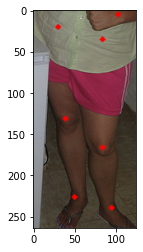

In [44]:
while i < total_imgs:
    
    clear_output(wait=True)
    
    _img_det = df1.iloc[i]

    img = cv2.imread(os.path.join(ds_root_path, imgs_path, _img_det['file_name']))
    
    kp = to_kp_format(_img_det['keypoints'])
    
    cropped_img, top, left = crop_image_by_kp(img, kp)
    
    new_img_det = reset_img_details(_img_det.copy(), cropped_img, top, left)
    
    keypoints_df = keypoints_df.append(new_img_det)
    
    plt.imshow(rgb(draw_kp_on_image(cropped_img, new_img_det['keypoints'], lines=False)))
    plt.show()

    plt.imsave(os.path.join(ds_root_path, 'legs_train/data', _img_det['file_name']), rgb(cropped_img))
    
    i += 1

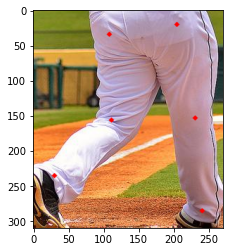

In [149]:
j = np.random.randint(0, high=total_imgs)
img = cv2.imread(os.path.join(ds_root_path, 'legs_train/data', keypoints_df.iloc[j]['file_name']))

plt.imshow(rgb(draw_kp_on_image(img, keypoints_df.iloc[j]['keypoints'], lines=False)))

In [532]:
keypoints_df.to_csv(os.path.join(ds_root_path, 'legs_train/keypoints', 'one_person.csv'))

# Crop Images with More Person

In [152]:
annotations_df2 = annotations_df[annotations_df['image_id'].isin((annotations_df['image_id'].value_counts() > 1).mask(lambda x: x == False).dropna().index)]

In [153]:
annotations_df2

,segmentation,num_keypoints,area,iscrowd,keypoints,image_id,bbox,category_id,id
15,"[[313.06, 314.56, 327.74, 314.56, 334.69, 320....",13,9245.76135,0,"[306, 330, 2, 310, 326, 2, 0, 0, 0, 320, 331, ...",494014,"[293.84, 314.56, 70.2, 221.69]",1,183503
17,"[[179.58, 176.9, 180.23, 156.68, 195.23, 160.5...",11,3463.45420,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 193, 88, 2, 211, 8...",390348,"[167.11, 74.51, 72.06, 125.9]",1,183559
19,"[[521.61, 255.64, 534.32, 248.83, 532.96, 235....",16,1467.99315,0,"[539, 195, 2, 542, 194, 2, 538, 193, 2, 0, 0, ...",128119,"[521.16, 187.1, 28.59, 85.78]",1,183692
20,"[[103.8, 173.86, 95.72, 168.09, 99.95, 160.01,...",15,2715.66095,0,"[102, 170, 2, 102, 168, 2, 0, 0, 0, 107, 166, ...",246265,"[81.49, 158.47, 52.7, 97.32]",1,183761
24,"[[573.01, 93.44, 579.4, 92.28, 582.89, 97.51, ...",15,2720.57095,0,"[573, 107, 2, 576, 104, 2, 571, 104, 2, 580, 1...",101013,"[565.78, 92.28, 40.02, 140.64]",1,183924
...,...,...,...,...,...,...,...,...,...
262458,"{'counts': [349, 8, 28, 6, 308, 7, 2, 14, 1, 3...",0,33654.00000,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",292554,"[0, 93, 630, 328]",1,900100292554
262460,"{'counts': [4138, 7, 418, 12, 413, 14, 1, 2, 1...",0,23580.00000,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",128732,"[9, 284, 560, 141]",1,900100128732
262461,"{'counts': [111472, 7, 365, 11, 362, 13, 360, ...",0,25439.00000,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",489186,"[298, 0, 341, 127]",1,900100489186
262462,"{'counts': [13254, 1, 316, 4, 6, 1, 315, 7, 31...",0,4227.00000,1,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",390883,"[40, 104, 394, 43]",1,900100390883


In [154]:
images_df2 = images_df[images_df['id'].isin(annotations_df2['image_id'].to_list())]

In [155]:
images_df2

,license,file_name,coco_url,height,width,date_captured,flickr_url,id
0,3,000000391895.jpg,http://images.cocodataset.org/train2017/000000...,360,640,2013-11-14 11:18:45,http://farm9.staticflickr.com/8186/8119368305_...,391895
2,3,000000184613.jpg,http://images.cocodataset.org/train2017/000000...,336,500,2013-11-14 12:36:29,http://farm3.staticflickr.com/2169/2118578392_...,184613
8,2,000000005802.jpg,http://images.cocodataset.org/train2017/000000...,479,640,2013-11-14 17:28:25,http://farm4.staticflickr.com/3810/9614287841_...,5802
18,3,000000293802.jpg,http://images.cocodataset.org/train2017/000000...,640,425,2013-11-14 20:28:50,http://farm4.staticflickr.com/3017/2502287818_...,293802
20,3,000000372938.jpg,http://images.cocodataset.org/train2017/000000...,424,640,2013-11-14 20:57:14,http://farm4.staticflickr.com/3282/2628517227_...,372938
...,...,...,...,...,...,...,...,...
118203,1,000000547777.jpg,http://images.cocodataset.org/train2017/000000...,480,640,2013-11-23 03:22:45,http://farm3.staticflickr.com/2772/4323367770_...,547777
118205,4,000000375321.jpg,http://images.cocodataset.org/train2017/000000...,375,500,2013-11-23 05:41:22,http://farm1.staticflickr.com/20/72635410_fc05...,375321
118211,5,000000545549.jpg,http://images.cocodataset.org/train2017/000000...,480,640,2013-11-24 00:18:29,http://farm4.staticflickr.com/3670/9309814055_...,545549
118229,1,000000445671.jpg,http://images.cocodataset.org/train2017/000000...,540,640,2013-11-24 05:42:54,http://farm3.staticflickr.com/2072/2245659084_...,445671


In [512]:
df2 = pd.merge(images_df2, annotations_df2, left_on='id', right_on='image_id').rename(columns={'id_x': 'id'})

In [513]:
df2

,license,file_name,coco_url,height,width,date_captured,flickr_url,id,segmentation,num_keypoints,area,iscrowd,keypoints,image_id,bbox,category_id,id_y
0,3,000000391895.jpg,http://images.cocodataset.org/train2017/000000...,360,640,2013-11-14 11:18:45,http://farm9.staticflickr.com/8186/8119368305_...,391895,"[[352.55, 146.82, 353.61, 137.66, 356.07, 112....",14,14107.27130,0,"[368, 61, 1, 369, 52, 2, 0, 0, 0, 382, 48, 2, ...",391895,"[339.88, 22.16, 153.88, 300.73]",1,202758
1,3,000000391895.jpg,http://images.cocodataset.org/train2017/000000...,360,640,2013-11-14 11:18:45,http://farm9.staticflickr.com/8186/8119368305_...,391895,"[[477.41, 217.71, 475.06, 212.15, 473.78, 208....",0,708.26055,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",391895,"[471.64, 172.82, 35.92, 48.1]",1,1260346
2,3,000000184613.jpg,http://images.cocodataset.org/train2017/000000...,336,500,2013-11-14 12:36:29,http://farm3.staticflickr.com/2169/2118578392_...,184613,"[[218.21, 280.88, 215.95, 293.72, 203.87, 290....",16,11210.37590,0,"[215, 103, 2, 219, 97, 2, 209, 99, 2, 0, 0, 0,...",184613,"[146.48, 65.69, 160.83, 246.9]",1,1202318
3,3,000000184613.jpg,http://images.cocodataset.org/train2017/000000...,336,500,2013-11-14 12:36:29,http://farm3.staticflickr.com/2169/2118578392_...,184613,"[[57.26, 164.23, 59.52, 179.3, 63.28, 187.59, ...",14,4457.00885,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 20, 78, 2, 36, 71,...",184613,"[8.29, 57.26, 75.33, 146.9]",1,1236161
4,3,000000184613.jpg,http://images.cocodataset.org/train2017/000000...,336,500,2013-11-14 12:36:29,http://farm3.staticflickr.com/2169/2118578392_...,184613,"[[45.24, 48.41, 52.61, 48.41, 56.95, 48.63, 60...",5,1700.75900,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 50, 63, 1, 0, 0, 0...",184613,"[45.24, 48.41, 45.97, 125.55]",1,1250302
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152706,3,000000439057.jpg,http://images.cocodataset.org/train2017/000000...,480,640,2013-11-24 15:43:45,http://farm9.staticflickr.com/8434/7874312066_...,439057,"[[122.94, 445.43, 121.84, 423.54, 123.6, 414.7...",0,352.35800,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",439057,"[121.84, 404.3, 11.49, 42.9]",1,1703473
152707,3,000000439057.jpg,http://images.cocodataset.org/train2017/000000...,480,640,2013-11-24 15:43:45,http://farm9.staticflickr.com/8434/7874312066_...,439057,"[[385.42, 430.68, 385.42, 422.92, 386, 419.03,...",0,112.19380,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",439057,"[377.89, 411.61, 9.13, 20.78]",1,1704772
152708,3,000000439057.jpg,http://images.cocodataset.org/train2017/000000...,480,640,2013-11-24 15:43:45,http://farm9.staticflickr.com/8434/7874312066_...,439057,"[[350.69, 434.93, 349.62, 434.48, 349.71, 426....",0,119.45785,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",439057,"[347.49, 411.71, 8, 23.48]",1,1704833
152709,3,000000439057.jpg,http://images.cocodataset.org/train2017/000000...,480,640,2013-11-24 15:43:45,http://farm9.staticflickr.com/8434/7874312066_...,439057,"[[140.72, 439.04, 141.13, 434.41, 141.85, 439....",0,154.26810,0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",439057,"[138.15, 413.23, 9.04, 26.02]",1,2024006


## Remove Images with Overlapping BBox

3996
Total Annotaions: 14


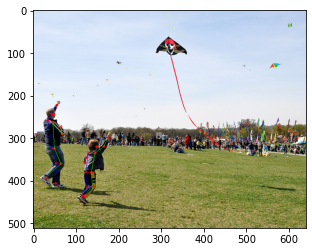

In [454]:
j = np.random.randint(0, high=total_imgs)
print(j)
img = cv2.imread(os.path.join(ds_root_path, imgs_path, df2.iloc[j]['file_name']))

_img_det = df2.iloc[j]

_annot = df2.loc[df2['id'] == _img_det['id']]
print('Total Annotaions:', _annot.__len__())

frame = img.copy()
for i in _annot.index:
    frame = draw_kp_on_image(frame, to_kp_format(_annot.loc[i]['keypoints']), lines=True)

plt.imshow(rgb(frame))

In [473]:
images_df2.shape, annotations_df2.shape

((22619, 8), (152711, 9))

## Applying Filter to Get Indexes with No Overlapping

In [474]:
filtered_annot_indexes = list()

for ind in images_df2.index:
    clear_output()
    print(ind)

    img = cv2.imread(os.path.join(ds_root_path, imgs_path, images_df2.loc[ind]['file_name']))

    _img_det = images_df2.loc[ind]

    _annot = annotations_df2.loc[annotations_df2['id'] == _img_det['id']]

    low_conf_indexes = list()
    for i in range(len(_annot)):
        low_conf_indexes.extend(get_lower_confidence(_annot, i))
    _annot = _annot.drop(low_conf_indexes)

    overlapped_indexes = list()
    for i in range(len(_annot) - 1):
        overlapped_indexes.extend(find_overlapping(img, _annot, overlapping_kps, i, i+1))
    _annot = _annot.drop(overlapped_indexes)
    
    filtered_annot_indexes.extend(_annot.index.to_list())
    

118259


In [529]:
df2_filtered = df2.loc[df2['id_y'].isin(annotations_df2.loc[filtered_annot_indexes]['id'])]

In [530]:
df2_filtered.shape

(1115, 17)

In [557]:
total_imgs = len(df2_filtered)

In [558]:
i = 0

In [559]:
keypoints_df2 = pd.DataFrame()

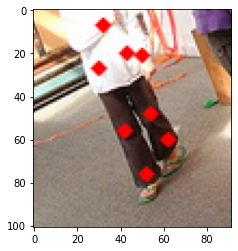

In [561]:
while i < total_imgs:
    
    clear_output(wait=True)
    
    _img_det = df2_filtered.iloc[i]

    img = cv2.imread(os.path.join(ds_root_path, imgs_path, _img_det['file_name']))
    
    kp = to_kp_format(_img_det['keypoints'])
    
    cropped_img, top, left = crop_image_by_kp(img, kp)
    
    new_img_det = reset_img_details(_img_det.copy(), cropped_img, top, left)
    new_img_det['file_name'] = f"{new_img_det['id_y']}.jpg"
    
    keypoints_df2 = keypoints_df2.append(new_img_det)
    
    plt.imshow(rgb(draw_kp_on_image(cropped_img, new_img_det['keypoints'], lines=False)))
    plt.show()

    plt.imsave(os.path.join(ds_root_path, 'legs_train/data2', new_img_det['file_name']), rgb(cropped_img))
    
    i += 1

In [563]:
keypoints_df2.to_csv(os.path.join(ds_root_path, 'legs_train/keypoints', 'multi_person.csv'))

We've only 11070 Images

## Rough

40661
Total Annotaions: 8


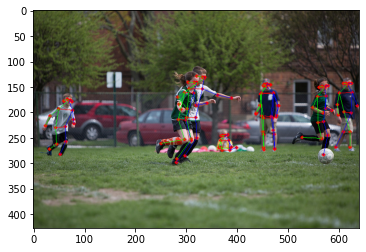

Int64Index([40658, 40659, 40660, 40661, 40662, 40663, 40664, 40665], dtype='int64')


In [517]:
j = 40661 # df2.sample().index[0]
print(j)
img = cv2.imread(os.path.join(ds_root_path, imgs_path, df2.loc[j]['file_name']))

_img_det = df2.loc[j]

_annot = df2.loc[df2['id'] == _img_det['id']]
print('Total Annotaions:', _annot.__len__())

frame = img.copy()
for i in _annot.index:
    frame = draw_kp_on_image(frame, to_kp_format(_annot.loc[i]['keypoints']), lines=True)

plt.imshow(rgb(frame))
plt.show()
print(_annot.index)

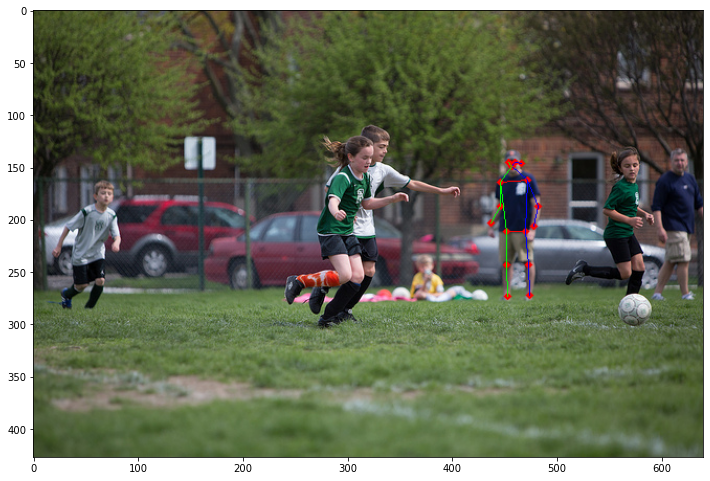

In [528]:
plt.figure(figsize=(12,12))
plt.imshow(rgb(draw_kp_on_image(img, to_kp_format(_annot.loc[40659]['keypoints']), lines=True)))

In [ ]:
low_conf_indexes = list()
for i in range(len(_annot)):
    low_conf_indexes.extend(get_lower_confidence(_annot, i))
_annot = _annot.drop(low_conf_indexes)

In [ ]:
overlapped_indexes = list()
for i in range(len(_annot) - 1):
    overlapped_indexes.extend(find_overlapping(img, _annot, overlapping_kps, i, i+1))
_annot = _annot.drop(overlapped_indexes)

In [ ]:
filtered_annot_indexes.extend(_annot.index.to_list())

In [391]:
to_kp_format(_annot.iloc[0]['keypoints'])[9:]

array([[618, 206,   2],
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0],
       [632, 407,   2],
       [  0,   0,   0],
       [  0,   0,   0],
       [  0,   0,   0]])

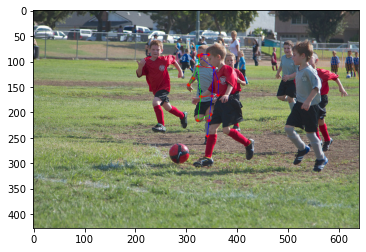

In [300]:
plt.imshow(rgb(draw_kp_on_image(img, to_kp_format(_annot.loc[7584]['keypoints']), lines=True)))

In [246]:
topA, bottomA, leftA, rightA = crop_image_by_kp(img, to_kp_format(_annot['keypoints'].iloc[0]), only_area=True)

In [262]:
(to_kp_format(_annot['keypoints'].iloc[1])[[11,12,15,16], 2] > 0).sum() == 4

False

In [265]:
topB, bottomB, leftB, rightB = crop_image_by_kp(img, to_kp_format(_annot['keypoints'].iloc[3]), only_area=True)

In [266]:
topA, bottomA, leftA, rightA, topB, bottomB, leftB, rightB

(204, 376, 70, 177, 190, 411, 310, 423)

In [236]:
overlapping_boxes = list()
i = 1
for i in range(len(_annot) - 1):
    if (_annot['bbox'].iloc[i][0] <= _annot['bbox'].iloc[i+1][0] <= (_annot['bbox'].iloc[i][0] + _annot['bbox'].iloc[i][2]))\
        or\
        (_annot['bbox'].iloc[i][1] <= _annot['bbox'].iloc[i+1][1] <= (_annot['bbox'].iloc[i][1] + _annot['bbox'].iloc[i][3])):
            overlapping_boxes.extend([_annot.iloc[i].name, _annot.iloc[i+1].name])
        
overlapping_boxes = np.unique(overlapping_boxes)
        
        

In [238]:
rem_kps = np.setdiff1d(_annot.index, overlapping_boxes)

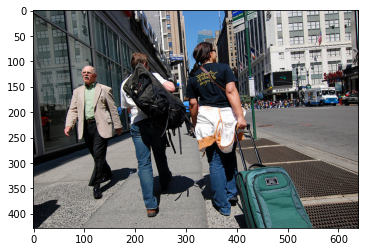

In [280]:
frame = img.copy()
for i in overlapping_kps:
    frame = draw_kp_on_image(frame, to_kp_format(_annot.loc[i]['keypoints']), lines=True)

plt.imshow(rgb(frame))

# Test

In [946]:
_img_det = df1.iloc[4]

img = cv2.imread(os.path.join(ds_root_path, imgs_path, _img_det['file_name']))

kps = to_kp_format(_img_det['keypoints'])

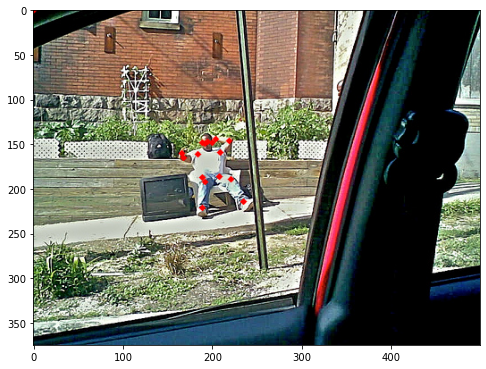

In [947]:
plt.figure(figsize=(8,8))
plt.imshow(rgb(draw_kp_on_image(img, to_kp_format(_img_det['keypoints']))))

In [948]:
h, w = img.shape[:2]

In [949]:
kps = kps[9:]

In [950]:
kp = kps.copy()

In [951]:
for i in range(3,5):
    if kp[i, 2] == 0:
        kp[i, :] =  kp[i+2, :]

In [952]:
kp = kp[:, :2]

In [953]:
x1, y1 = kp[2]
x2, y2 = kp[3]
x3, y3 = kp[4]
x4, y4 = kp[5]
x5, y5 = kp[6]
x6, y6 = kp[7]

In [954]:
 x1,  y1,  x2,  y2,  x3,  y3,  x4,  y4,  x5,  y5,  x6,  y6

(208, 186, 189, 187, 221, 189, 192, 192, 235, 214, 189, 221)

In [955]:
if x1 > x2:
    x2, y2, x1, y1, x6, y6, x5, y5 = x1, y1, x2, y2, x5, y5, x6, y6
if y1 > y5:
    x5, y5, x2, y6, x6, y1, x2, y2 = x1, y1, x2, y2, x5, y5, x6, y6

In [956]:
# Top-Bottom and Left-Right crop area

tb_crop_area = 20 #int(0.1 * (h - y1))
lr_crop_area = 30 #int(0.15 * (w - x1))

top = max(0, min(y1, y2, y3, y4, y5, y6) - tb_crop_area)
bottom = min(h, max(y1, y2, y3, y4, y5, y6) + tb_crop_area + 5)
left = max(0, min(x1, x2, x3, x4, x5, x6) - lr_crop_area)
right = min(w, max(x1, x2, x3, x4, x5, x6) + lr_crop_area)

cropped_img = img[top:bottom , left:right]

In [957]:
top, bottom, left, right

(166, 246, 159, 265)

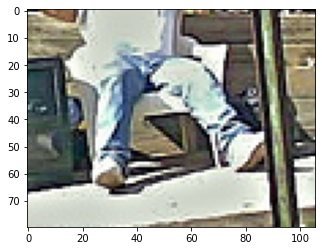

In [958]:
plt.imshow(rgb(cropped_img))

In [959]:
kps

array([[204, 144,   2],
       [166, 160,   2],
       [208, 186,   2],
       [189, 187,   2],
       [221, 189,   2],
       [192, 192,   2],
       [235, 214,   2],
       [189, 221,   2]])

In [960]:
h, w = cropped_img.shape[:2]

In [971]:
kp = kps.copy()

In [962]:
_img_det['height'], _img_det['width'] = cropped_img.shape[:2]

/home/usman/anaconda3/envs/truetoform/lib/python3.9/site-packages/pandas/core/series.py:1056: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cacher_needs_updating = self._check_is_chained_assignment_possible()


In [963]:
_img_det['num_keypoints'] = kp[kp[:, 2] > 0].shape[0]

In [964]:
_img_det.drop(['area', 'iscrowd', 'bbox', 'segmentation'], inplace=True)

/home/usman/anaconda3/envs/truetoform/lib/python3.9/site-packages/pandas/core/generic.py:4153: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._update_inplace(obj)


In [972]:
kp[:, 0] = kp[:, 0] - left
kp[:, 1] = kp[:, 1] - top

In [973]:
kp

array([[ 45, -22,   2],
       [  7,  -6,   2],
       [ 49,  20,   2],
       [ 30,  21,   2],
       [ 62,  23,   2],
       [ 33,  26,   2],
       [ 76,  48,   2],
       [ 30,  55,   2]])

In [977]:
kp[(kp[:, 0] < 0) | (kp[:, 1] < 0), 2] = 0

In [979]:
kp[kp < 0] = 0

In [980]:
_img_det['keypoints'] = kp

In [906]:
_img_det

license                                                          6
file_name                                         000000554114.jpg
coco_url         http://images.cocodataset.org/train2017/000000...
height                                                         197
width                                                          232
date_captured                                  2013-11-17 10:55:20
flickr_url       http://farm5.staticflickr.com/4081/4742860152_...
id                                                          554114
num_keypoints                                                    8
keypoints        [[17, 74, 2], [0, 67, 2], [158, 23, 2], [94, 2...
image_id                                                    554114
category_id                                                      1
id_y                                                        425233
Name: 7, dtype: object

In [990]:
def draw_kp_on_image(img, kps, confidence=0.5):
    img = img.copy()
    point_shape = {'color':(0, 0, 255), 
                 'markerType':cv2.MARKER_CROSS, 
                 'markerSize':5, 
                 'thickness':2, 
                 'line_type':cv2.LINE_AA}
    for kp in kps:
        if kp[2] < confidence:
            continue
        img = cv2.drawMarker(
            img,
            tuple(kp[:2]),
        **point_shape
        )
    return img

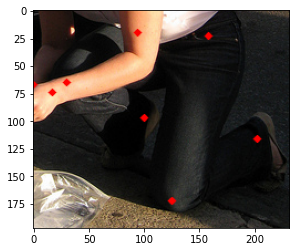

In [908]:
plt.imshow(rgb(draw_kp_on_image(cropped_img, kp)))

In [881]:
_img_det = df1.iloc[7]
img = cv2.imread(os.path.join(ds_root_path, imgs_path, _img_det['file_name']))
kp = to_kp_format(_img_det['keypoints'])
cropped_img = crop_image_by_kp(img, kp)

In [882]:
new_img_det = reset_img_details(_img_det, cropped_img)

/home/usman/anaconda3/envs/truetoform/lib/python3.9/site-packages/pandas/core/series.py:1056: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cacher_needs_updating = self._check_is_chained_assignment_possible()
/home/usman/anaconda3/envs/truetoform/lib/python3.9/site-packages/pandas/core/generic.py:4153: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._update_inplace(obj)


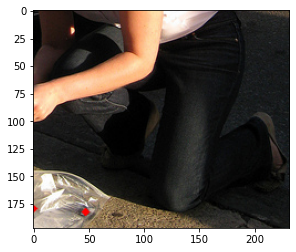

In [883]:
plt.imshow(rgb(draw_kp_on_image(cropped_img, new_img_det['keypoints'])))